<a href="https://colab.research.google.com/github/Vitela-debug/Colab_S1_Clase-de-progralaci-n_273522_TVB/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo_TVB_273522.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Tania Vitela Barraza
- **Matrícula:** 273522

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [40]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.
print('Media:', df['price'].mean())
print('Mediana:', df['price'].median() )
print('Moda:', df['price'].mode())

#En este primer ejercio se utilizó .mean() para la media, .median() para la mediana
# y .mode()  para la moda


Media: 152.7206871868289
Mediana: 106.0
Moda: 0    100
Name: price, dtype: int64


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_

La media y la mediana divergen mucho. Lo que sugiere que existen valores extremos altos en price, probablemente debido a la presencia de valores extremos (outliers), que elevan la media y hacen que la distribución esté sesgada hacia la derecha.

---
## Actividad 2 — Dispersión (20 pts)

In [41]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.
rango = df['price'].max() - df['price'].min() #para calcular el rango mediante la resta de maximo menos minimo
varianza = df['price'].var() #para calcular la varianza
desviacion = df['price'].std() #calcular la desviacion estandar

print(f'Valor máximo:',                df['price'].max()) #para ver el valor max
print(f'Valor mínimo:',                df['price'].min()) #para ver el valor minimo
print(f'Rango:               {rango:,.2f}')
print(f'Varianza:            {varianza:,.2f}')
print(f'Desviación estándar: {desviacion:,.2f}')

Q1 = df['price'].quantile(0.25) #calcula el primer cuartil
Q3 = df['price'].quantile(0.75) #calcula el tercer cuartil
IQR = Q3 - Q1# calcula el rnago intercuartilico mediante una resta (representa el 50% del centro de los datos)

print(f'Q1 (percentil 25): {Q1:,.2f}')
print(f'Q3 (percentil 75): {Q3:,.2f}')
print(f'IQR:                {IQR:,.2f}')

#desviación estándar y el IQR para saber qué tan separados están los datos
#El código del ejercicio 2 analiza la dispersión de los precios: calcula el rango, varianza,
# y detectar posibles valores extremos.


Valor máximo: 10000
Valor mínimo: 0
Rango:               10,000.00
Varianza:            57,674.03
Desviación estándar: 240.15
Q1 (percentil 25): 69.00
Q3 (percentil 75): 175.00
IQR:                106.00


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_

El IQR (106) me parece más representativo de la dispersión típica de los precios, porque el rango (10,000) está muy afectado por el valor máximo de 10,000, que parece ser un valor extremo. El IQR representa mejor cómo se distribuye el 50% central de los precios.

---
## Actividad 3 — Forma (20 pts)

In [42]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
print('Asimetría de price (con outlier):   ', df['price'].skew()) #para calcular la asimetría de price con outlier
print('Asimetría de price (sin outlier):   ', df[df['price']!= 10000]['price'].skew()) #para calcular la asimetría de price sin outlier
print('Curtosis de price (con outlier):', df['price'].kurt())  #para calcular la curtosis de price con outlier
print('Curtosis de price (sin outlier):', df[df['price'] != 10000]['price'].kurt()) #para calcular la curtosis de price sin outlier

#Este código calcula la asimetría y curtosis de price con y sin el valor extremo de 10000,
 #para ver cómo afecta ese outlier a la distribución de los precios.

Asimetría de price (con outlier):    19.118938995046033
Asimetría de price (sin outlier):    17.537796724130484
Curtosis de price (con outlier): 585.6728788988286
Curtosis de price (sin outlier): 513.3790135058739


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_

Los valores de price son mucho más altos que los de Income: la asimetría es 19.12 vs. 6.76 y la curtosis 585.67 vs. 159.6. Esto indica una distribución mucho más sesgada y con mayor presencia de valores extremos. Por eso, en la próxima etapa de Datos Atípicos, esperaría encontrar varios valores que afectan significativamente la distribución de price.

---
## Actividad 4 — Visualización (30 pts)

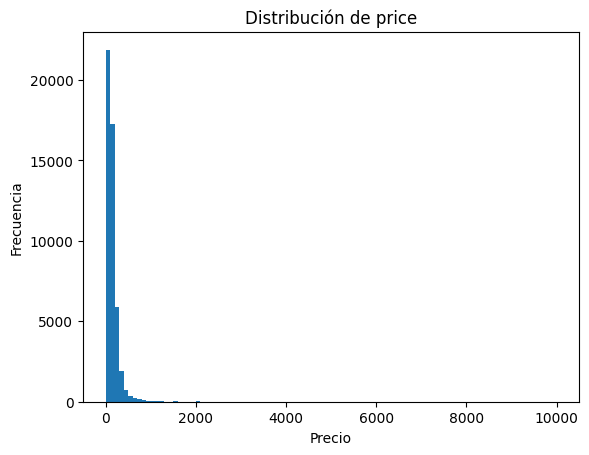

In [43]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.

df['price'].plot(kind='hist', bins=100, title='Distribución de price')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

#Se eligieron 100 bins porque permiten observar de forma clara y a detalle cómo se distribuyen los precios
#y detectar posibles valores extremos sin que el histograma quede demasiado
#agrupado (como es el caso de los numeros menores) o demasiado dividido. Es decir si aumentamos bins, hay más barras y se ve
# más detalle (lo que sirve en este caso), si lo disminuimos, hay menos barras y el gráfico se ve más general


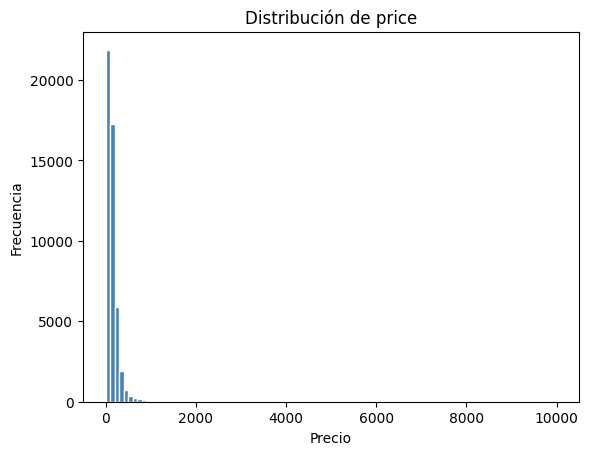

In [44]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.

plt.hist(df['price'], bins=100, color='steelblue', edgecolor='white')
plt.title('Distribución de price')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()


# código hace un histograma de price para ver cómo se distribuyen los precios.
#nuevamente se escogió bins=100 por que divide los datos en 100 grupos.
# Si aumentamos bins, hay más barras y se ve más detalle (lo que sirve en este caso),
# si lo disminuimos, hay menos barras y el gráfico se ve más general


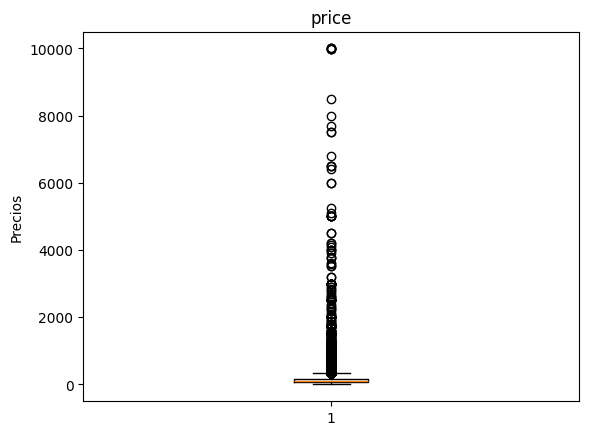

In [45]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).

plt.boxplot(df['price'])
plt.title('price')
plt.ylabel('Precios')
plt.show()

#El código del ejerciocios 4.3 sirve para hacer un boxplot de los precios y así poder observar
#como están distribuidos, cuál es la mediana, qué tan dispersos están los precios y,
# sobre todo, identificar los valores atípicos


**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_

En el histograma de price se puede observar que la mayoría de los precios se encuentran concentrados en valores relativamente bajos, mientras que una cantidad menor de datos se extiende hacia valores mucho más altos (que casi no son visibles pero sabemos que estan ahí en menor frecuencia por los calculos previos), formando una cola larga hacia la derecha. Esto indica que la distribución de price está fuertemente sesgada hacia la derecha. En el boxplot esta situación se observa todavía más claramente, ya que la caja y los bigotes se encuentran concentrados en la parte inferior, mientras que aparecen muchos puntos alejados por encima del bigote superior. Estos puntos representan los valores atípicos (outliers), algunos de los cuales llegan hasta aproximadamente 10,000. Aunque los outliers también se pueden notar en el histograma por la cola larga, es en el boxplot donde se distinguen mejor, porque cada punto representa un valor que se encuentra fuera del rango esperado. Esto coincide con los valores que calculamos anteriormente: una asimetría de 19.12 y una curtosis de 585.67 con el outlier incluido. Estos valores son bastante altos y muestran que price tiene una distribución muy sesgada y con una gran cantidad de valores extremos. Además, al comparar con Income, cuya asimetría fue de 6.76 y curtosis de 159.6, price presenta una mayor influencia de los valores atípicos.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_


Si tuviera que explicarle a alguien por qué el precio promedio de 152.72 puede ser engañoso, le diría que este valor no representa necesariamente lo que cuesta la mayoría de los datos. Por ejemplo, la media es 152.72, pero la mediana es 106, lo que significa que la mitad de los precios está por debajo de $106 y la otra mitad por encima. Además, el precio máximo llega hasta 10000, mientras que el mínimo es 0, por lo que existen valores extremos que hacen que la media aumente. Esto también se refleja en la desviación estándar de 240.15, que indica que los precios están bastante dispersos alrededor de la media. Por eso, el promedio de 152.72 puede dar la impresión de que los precios normalmente están cerca de esa cantidad, cuando en realidad la mayoría se concentra en valores más bajos y algunos precios muy altos elevan considerablemente la media.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |